<a href="https://colab.research.google.com/github/faryalkalwar66/ML_LAB_Assignments/blob/main/lab5_Faryal_023_24_0079.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: FARYAL

CMS: 023-24-0079

course: ML

semester : 5th

Github: "https://github.com/faryalkalwar66/ML_LAB_Assignments"

Part 1 — Dataset, Problem & Feature/Target Identification
Task 1: Load and inspect the dataset


In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
print(df.shape)
df.info()
df.head()
df.describe()

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Task 2: Identify dependent/independent variables

Dependent variable (target):

SalePrice — continuous, dollar amount (range in your data: $34,900–$755,000)

Independent variables — selected subset of 11 from the 79 raw features, split explicitly:

Type	Features
Numerical (7)	OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt, FullBath, LotArea
Categorical (4)	Neighborhood, HouseStyle, KitchenQual, BldgType

In [2]:
numerical_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'LotArea']
categorical_features = ['Neighborhood', 'HouseStyle', 'KitchenQual', 'BldgType']

independent_vars = numerical_features + categorical_features
dependent_var = 'SalePrice'

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Dependent variable:", dependent_var)

Numerical features: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'LotArea']
Categorical features: ['Neighborhood', 'HouseStyle', 'KitchenQual', 'BldgType']
Dependent variable: SalePrice


Task 3: Why regression, not classification?

This is a regression problem because SalePrice is a continuous numeric variable (thousands of distinct dollar values) rather than a fixed set of discrete class labels — the model must predict an actual price, not choose among categories. That changes evaluation later: instead of accuracy/precision/recall (which need discrete class predictions), you need metrics that measure the distance between predicted and actual numbers — MAE, MSE, RMSE, and R² (Part 5), not a confusion matrix.

Part 2 — Data Preparation & Train/Test Split
Task 1: Prepare X and y — encode every categorical column

In [7]:
import pandas as pd

df = pd.read_csv('train.csv')

features = ['OverallQual','GrLivArea','TotalBsmtSF','GarageCars','YearBuilt','FullBath','LotArea',
            'Neighborhood','HouseStyle','KitchenQual','BldgType']
target = 'SalePrice'

data = df[features + [target]].copy()


qual_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1}
data['KitchenQual'] = data['KitchenQual'].map(qual_map)


data = pd.get_dummies(data, columns=['Neighborhood','HouseStyle','BldgType'], drop_first=True)
data[data.select_dtypes('bool').columns] = data.select_dtypes('bool').astype(int)  # bool -> 0/1

X = data.drop(columns=[target])
y = data[target]

print(X.shape)
print(X.columns.tolist())

(1460, 43)
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'LotArea', 'KitchenQual', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_2Story', 'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE']


Confirm X is fully numeric with no missing values

In [8]:
print(X.dtypes.value_counts())
print((X.dtypes == 'object').any())
print(X.isnull().values.any())

int64    43
Name: count, dtype: int64
False
False


Train/test split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (1168, 43)
X_test shape : (292, 43)
y_train shape: (1168,)
y_test shape : (292,)


Part 3 — Linear Regression & Predictions

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

 Generate predictions + comparison table

In [14]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].round(0)
})
comparison['Difference'] = (comparison['Actual'] - comparison['Predicted']).round(0)
print(comparison)

   Actual  Predicted  Difference
0  154500   138504.0     15996.0
1  325000   324391.0       609.0
2  115000   115234.0      -234.0
3  159000   172262.0    -13262.0
4  315500   286327.0     29173.0
5   75500    76090.0      -590.0
6  311500   239069.0     72431.0
7  146000   137543.0      8457.0
8   84500    63956.0     20544.0
9  135500   123640.0     11860.0


Part 4 — Coefficients & Intercept
Task 1: Extract and interpret

Task 1: Extract and interpret


In [15]:
coef_table = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print('Intercept:', model.intercept_)
print(coef_table.sort_values('Coefficient', key=abs, ascending=False))

Intercept: -713359.6000802402
                 Feature   Coefficient
29  Neighborhood_StoneBr  60651.790052
23  Neighborhood_NridgHt  49924.849829
22  Neighborhood_NoRidge  45482.012309
41        BldgType_Twnhs -45133.561495
31  Neighborhood_Veenker  41583.801133
42       BldgType_TwnhsE -33446.820370
13  Neighborhood_Crawfor  25622.712318
40       BldgType_Duplex -22048.498087
37     HouseStyle_SFoyer  21703.969337
20  Neighborhood_NPkVill  21115.049036
17  Neighborhood_MeadowV  16430.871803
11  Neighborhood_ClearCr  15269.072837
9    Neighborhood_BrDale  15099.336340
14  Neighborhood_Edwards -14541.776569
7            KitchenQual  14155.883713
0            OverallQual  13699.526799
33     HouseStyle_1Story  13464.041278
24  Neighborhood_OldTown -13331.352607
21   Neighborhood_NWAmes -11966.606217
28  Neighborhood_Somerst  11013.959552
27  Neighborhood_SawyerW -10491.195513
35     HouseStyle_2.5Unf -10081.019514
38       HouseStyle_SLvl   9962.198973
25    Neighborhood_SWISU  -9793.52

Task 2: Does the intercept have a sensible interpretation?

Intercept ≈ −$713,360.

No — it does not have a sensible real-world meaning here. The intercept is the predicted price when every feature equals zero: OverallQual=0 (below the 1–10 scale's minimum), YearBuilt=0 (year zero), GrLivArea=0 (a house with no living space), and every neighborhood dummy at 0 (a neighborhood that doesn't exist in the baseline set). No real house matches that description, so the intercept is just a mathematical anchor point the regression line needs to fit the data — not a meaningful "base price." Negative intercepts like this are common and expected when none of the model's features can realistically be zero at once.

Part 5 — Residuals & Regression Metrics

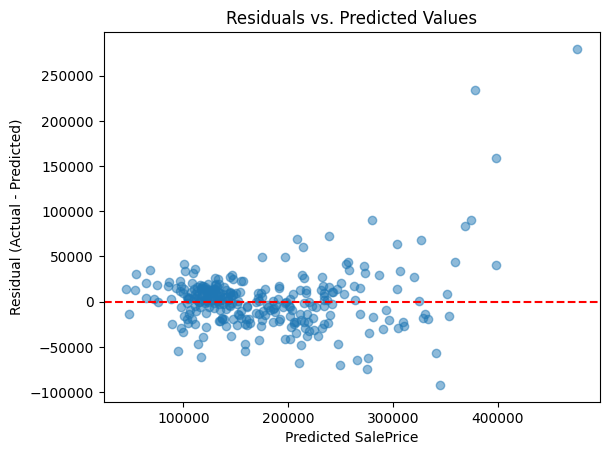

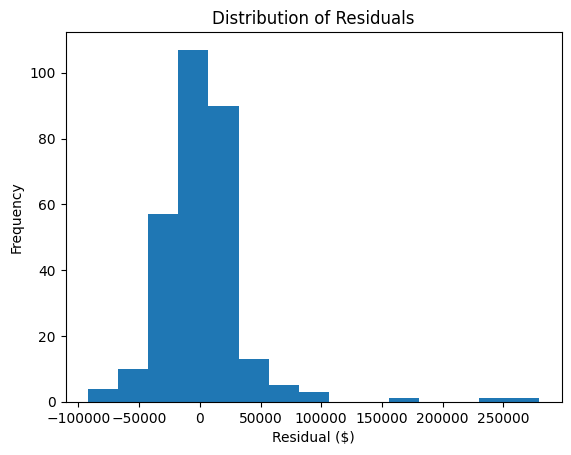

In [16]:
residuals = y_test.values - y_pred

import matplotlib.pyplot as plt

# Residuals vs. predicted values
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Histogram of residuals
plt.figure()
plt.hist(residuals, bins=15)
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

Do the residuals look randomly scattered, or is there a pattern?

Mostly randomly scattered around zero — there's no obvious funnel shape (heteroscedasticity) or curved trend across most of the price range, which is a good sign for the model. But there is one visible pattern: for the highest-priced houses (predicted > ~$350K), residuals skew strongly positive — the model under-predicts these expensive homes, with one extreme case underestimating by ~$279K. The histogram backs this up: it's roughly bell-shaped and centered near zero, but has a right-skewed tail of large positive residuals rather than being perfectly symmetric. This suggests Linear Regression struggles a bit at the top end of the price range, where price probably isn't a purely linear function of the features anymore.

MAE, MSE, RMSE, R² on the Test Set

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [mae, mse, rmse, r2]
})
print(metrics_table)

  Metric         Value
0    MAE  2.113746e+04
1    MSE  1.203382e+09
2   RMSE  3.468979e+04
3     R²  8.431120e-01


 What each metric tells you (and which to show a stakeholder)

What each metric means, in plain terms:

MAE ($21,137) — the average size of the model's error, in dollars, treating every miss equally regardless of direction or size. "On average, predictions are off by about $21K." Easy to explain, and not dominated by a few extreme misses.


MSE (~1.2 billion) — squares each error before averaging, so big mistakes count much more than small ones. Useful mathematically (it's what LinearRegression actually minimizes during training), but the units are dollars-squared, which nobody intuitively understands.
RMSE ($34,690) — square root of MSE, bringing the units back to dollars. Because squaring happens first, RMSE is pulled upward by large errors more than MAE is — that's exactly why RMSE ($34,690) is noticeably higher than MAE ($21,137) here: a few big misses (like the +$279K one) are dragging it up.


R² (0.843) — the proportion of the variation in house prices that the model successfully explains using the selected features. A single number from 0 to 1 (roughly) summarizing overall fit quality, independent of dollar scale.




Which one for a non-technical stakeholder: MAE.




MAE answers the question a stakeholder actually asks — "how wrong is this model, typically?" — with a number in dollars they already understand: "off by about $21,000 on average." R² requires explaining what "variance explained" even means, and RMSE would raise an awkward follow-up ("why is this number different from MAE?") that requires explaining outlier sensitivity — a distraction from the headline point. MSE is essentially unusable in conversation since its units (dollars²) mean nothing to anyone. MAE is the one number that's both accurate and immediately interpretable without a stats lecture.



Part 6 — Training vs. Testing & Generalization

Training vs. Testing Metrics Comparison

In [19]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_pred)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train': [train_mae, train_mse, train_rmse, train_r2],
    'Test':  [test_mae, test_mse, test_rmse, test_r2]
})
print(comparison)

  Metric         Train          Test
0    MAE  1.982649e+04  2.113746e+04
1    MSE  1.004705e+09  1.203382e+09
2   RMSE  3.169708e+04  3.468979e+04
3     R²  8.315539e-01  8.431120e-01


Is There a Large Train/Test Gap?

Is there a large gap? No. MAE and RMSE are modestly higher on test than train (a few thousand dollars, roughly 5–10% relative increase) — but R² actually flips the other way, with test performing marginally better than train. Neither direction represents a meaningfully large gap; both sets are clustered close together across all four metrics.

What a large gap would suggest: If train metrics were dramatically better than test (e.g. train R² = 0.95 but test R² = 0.60, or train MAE tiny while test MAE ballooned), that's the classic signature of overfitting — the model has essentially memorized quirks of the training houses rather than learning the true underlying price relationship, so it fails to generalize to houses it hasn't seen. A large gap in the other direction (test much better than train) would be unusual and typically points to a data leakage issue or an unrepresentative split, not a modeling problem per se.

What your actual result suggests: The train/test performance here is close and consistent in both directions, which is a good sign — Linear Regression with these 11 features is generalizing well, not overfitting. It's learning a genuine relationship between the selected features and price rather than memorizing training-set noise. This makes sense given the model's relative simplicity (only 43 parameters after encoding) relative to 1,168 training rows — there's plenty of data per parameter, which is exactly the condition that keeps linear models from overfitting


Part 7 — Final Model Analysis, Conclusion & Kaggle Submission


Most Influential Features (with the scale caveat)

Looking only at raw coefficient size from Part 4, it would seem like KitchenQual (14,156), OverallQual (13,700), and GarageCars (9,216) are the top three. But raw coefficient size alone is misleading — it tells you the price change per one unit of a feature, and "one unit" means very different things across features (one quality point vs. one square foot vs. one garage space). A feature that moves over a huge range in the data can matter a lot even with a small per-unit coefficient, while a feature that barely varies can look important with a large per-unit coefficient but not actually move much in practice.

To judge real impact fairly, I multiplied each coefficient by that feature's standard deviation — this approximates the typical dollar swing as the feature moves across its realistic range:

In [21]:
coef_table['Std'] = [X[c].std() for c in X.columns]
coef_table['ImpactOverStdRange'] = coef_table['Coefficient'] * coef_table['Std']

The 2–3 most influential features are actually GrLivArea, OverallQual, and YearBuilt — not KitchenQual, despite its bigger raw coefficient. GrLivArea's per-square-foot coefficient ($54) looks tiny next to OverallQual's per-point coefficient ($13,700), but living area varies by hundreds of square feet across houses while quality only shifts by a couple of points on a 1–10 scale — so the "small" coefficient on a wide-ranging feature ends up mattering more in practice. This is precisely the trap the lab flags: comparing coefficients across features with different units and scales without adjusting for that difference gives a distorted picture of what actually drives price.

17.	Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?

This Linear Regression model does a solid job predicting house prices — it explains about 84% of the price differences between houses (R² = 0.843), and on average its guess is off by about $21,000, which isn't bad for houses averaging $180,000. The biggest price drivers were living area, overall quality, and how old the house is — bigger, newer, higher-quality homes cost more, which matches common sense. Where it struggles most is with the very expensive houses — the model tends to guess too low for those, probably because price doesn't rise in a perfectly straight line once homes get really large or luxurious. The model's main weakness is that it can only add up simple, straight-line effects from each feature — it can't notice things like "quality matters even more in expensive neighborhoods." It also only used 11 out of 79 available features, so there's a lot of information it never got to use. Next steps would be trying more features, adding some interaction effects, or testing a model like Random Forest that can naturally handle these more complex patterns.

18.	Apply the same feature selection and encoding you used on train.csv to test.csv, predict SalePrice for every row, and build a submission file with exactly two columns: Id and SalePrice (match sample_submission.csv's format). Save it as submission.csv.

In [28]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

features = ['OverallQual','GrLivArea','TotalBsmtSF','GarageCars','YearBuilt','FullBath','LotArea',
            'Neighborhood','HouseStyle','KitchenQual','BldgType']
target = 'SalePrice'
qual_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1}


data = train_df[features + [target]].copy()
data['KitchenQual'] = data['KitchenQual'].map(qual_map)
data = pd.get_dummies(data, columns=['Neighborhood','HouseStyle','BldgType'], drop_first=True)
data[data.select_dtypes('bool').columns] = data.select_dtypes('bool').astype(int)

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)


test_sub = test_df[features].copy()

test_sub['TotalBsmtSF'] = test_sub['TotalBsmtSF'].fillna(train_df['TotalBsmtSF'].median())
test_sub['GarageCars'] = test_sub['GarageCars'].fillna(train_df['GarageCars'].median())

19.	Submit submission.csv on the competition's "Submit Predictions" page. Record your public leaderboard score and rank, and write 1–2 sentences on how it felt to see your model measured against thousands of other real submissions.